In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import skew, kurtosis
import re

In [2]:
df = pd.read_pickle("processed_dataset/final_dataset_new_features_all_logs_10s_window.pkl")

In [4]:
storage_read_cols = ['avg_ata_read', 'lba_read_var'] + [col for col in df.columns if 'strg_read' in col]
storage_write_cols = ['avg_ata_write', 'lba_write_var', 'avg_storage_entropy'] + [col for col in df.columns if 'strg_write' in col]

mem_write_cols = [col for col in df.columns if 'mem_write' in col]
mem_read_write_cols = [col for col in df.columns if 'mem_read_write' in col]
mem_exec_cols = [col for col in df.columns if 'mem_exec' in col]
mem_read_cols = [col for col in df.columns if 'mem_read' in col and col not in mem_read_write_cols]

target = 'is_ransomware'
operation_cols = ['operation', 'operation_log_cnt']

In [5]:
def timedelta_to_ns(t):
    if type(t) == pd.Timedelta:
        return t.total_seconds() * 1e9 + t.nanoseconds
    else:
        return t.total_seconds() * 1e9

In [ ]:
df = df.drop(columns = ['start', 'end'])

In [19]:
df.columns.to_list()

['avg_ata_read',
 'avg_ata_write',
 'lba_read_var',
 'lba_write_var',
 'avg_storage_entropy',
 'avg_entropy_mem_write',
 'avg_entropy_mem_read_write',
 'num_4KB_pages_mem_read',
 'num_4KB_pages_mem_write',
 'num_4KB_pages_mem_read_write',
 'num_4KB_pages_mem_exec',
 'num_2MB_pages_mem_read',
 'num_2MB_pages_mem_write',
 'num_2MB_pages_mem_read_write',
 'num_2MB_pages_mem_exec',
 'num_MMIO_pages_mem_read',
 'num_MMIO_pages_mem_write',
 'num_MMIO_pages_mem_read_write',
 'num_MMIO_pages_mem_exec',
 'gpa_mem_read_var',
 'gpa_mem_write_var',
 'gpa_mem_read_write_var',
 'gpa_mem_exec_var',
 'strg_write_high_entropy_count',
 'strg_write_max_entropy_jump',
 'strg_write_time_to_high_entropy',
 'strg_write_sustained_high_entropy_events',
 'strg_write_entropy_acceleration',
 'mem_write_high_entropy_count',
 'mem_write_max_entropy_jump',
 'mem_write_time_to_high_entropy',
 'mem_write_sustained_high_entropy_events',
 'mem_write_entropy_acceleration',
 'mem_read_write_high_entropy_count',
 'mem_read

In [ ]:
ransomware_colors = ['royalblue', 'tomato']
reverse_ransomware_colors = ['tomato', 'royalblue']
ransomware_colors_dict = {'True': 'tomato', 'False': 'royalblue', np.True_: 'tomato', np.False_: 'royalblue'}

ransomware_patch = mpatches.Patch(color=ransomware_colors[1], label='Ransomware')
benign_patch = mpatches.Patch(color=ransomware_colors[0], label='Non-Ransomware')

## Class Distribution

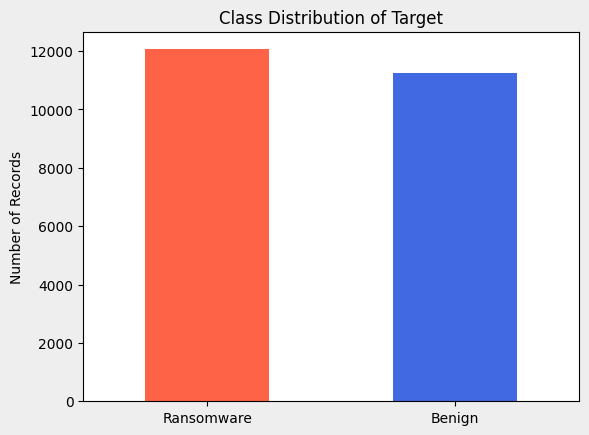

In [10]:
df['is_ransomware'].value_counts().plot(kind='bar', color=reverse_ransomware_colors);
plt.xlabel('')
plt.xticks(ticks=[0,1], labels=['Ransomware', 'Benign'], rotation=0)
plt.ylabel("Number of Records")
plt.title("Class Distribution of Target");
plt.gcf().set_facecolor("#eeeeeeff");

In [21]:
operation_group = df['operation'].value_counts().to_frame().reset_index()
operation_group['color'] = operation_group['operation'].apply(lambda x: ransomware_colors[1] if x in ["WannaCry", "Ryuk", "REvil", "LockBit", "Darkside", "Conti"] else ransomware_colors[0])
operation_group.index = operation_group['operation']

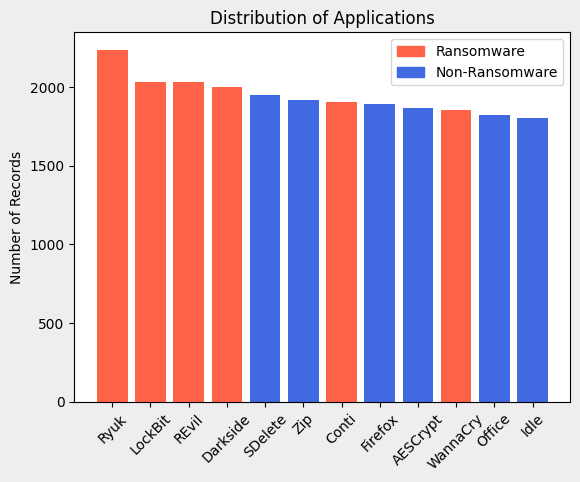

In [ ]:
plt.gcf().set_facecolor("#eeeeeeff")
plt.bar(operation_group['operation'], operation_group['count'], color=operation_group['color']);
plt.xticks(rotation=45)
plt.ylabel("Number of Records")

plt.legend(handles=[ransomware_patch, benign_patch])
plt.title("Distribution of Applications");

## NULL Analysis

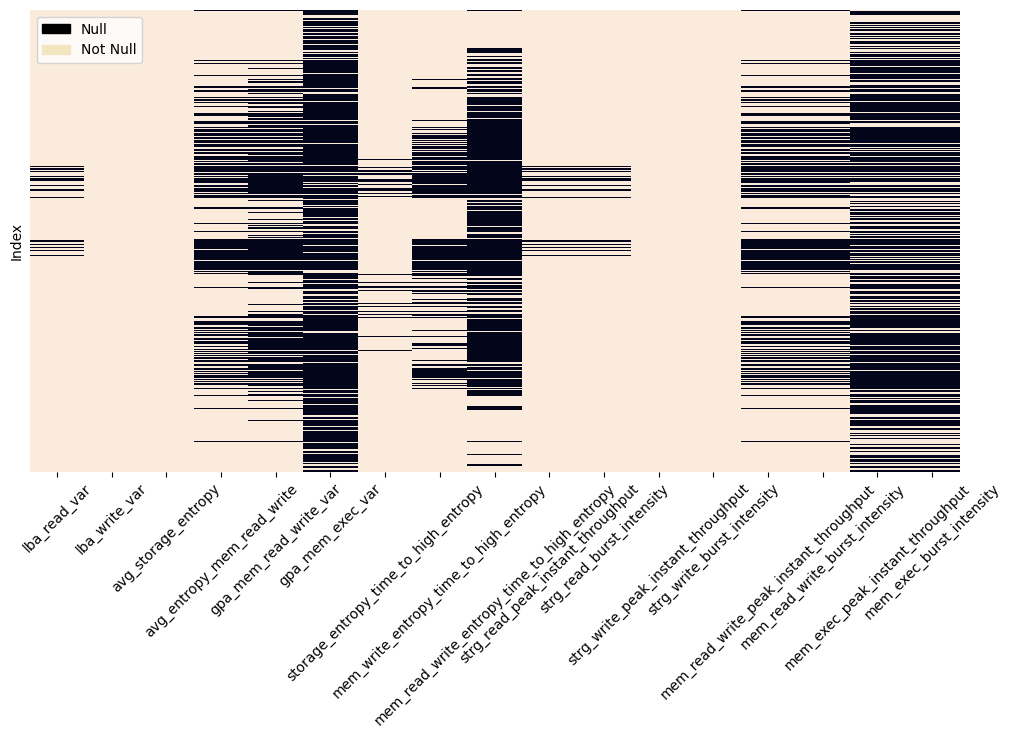

In [10]:
plt.figure(figsize=(12,6))
# plt.gcf().set_facecolor("#eeeeeeff")
sns.heatmap(df[df[df.columns[df.isna().sum() > 0]].isna().sum().index].notnull(), cbar=False)
plt.yticks([])
plt.ylabel("Index")
plt.xticks(rotation=45)

null_patch = mpatches.Patch(color='black', label='Null')
not_null_patch = mpatches.Patch(color='#f2e6c1', label='Not Null')
plt.legend(handles=[null_patch, not_null_patch], loc='upper left')
plt.savefig('./pics/null_analysis.png', bbox_inches='tight') 
# plt.title("Null Records in Features having Null values");

plt.show();

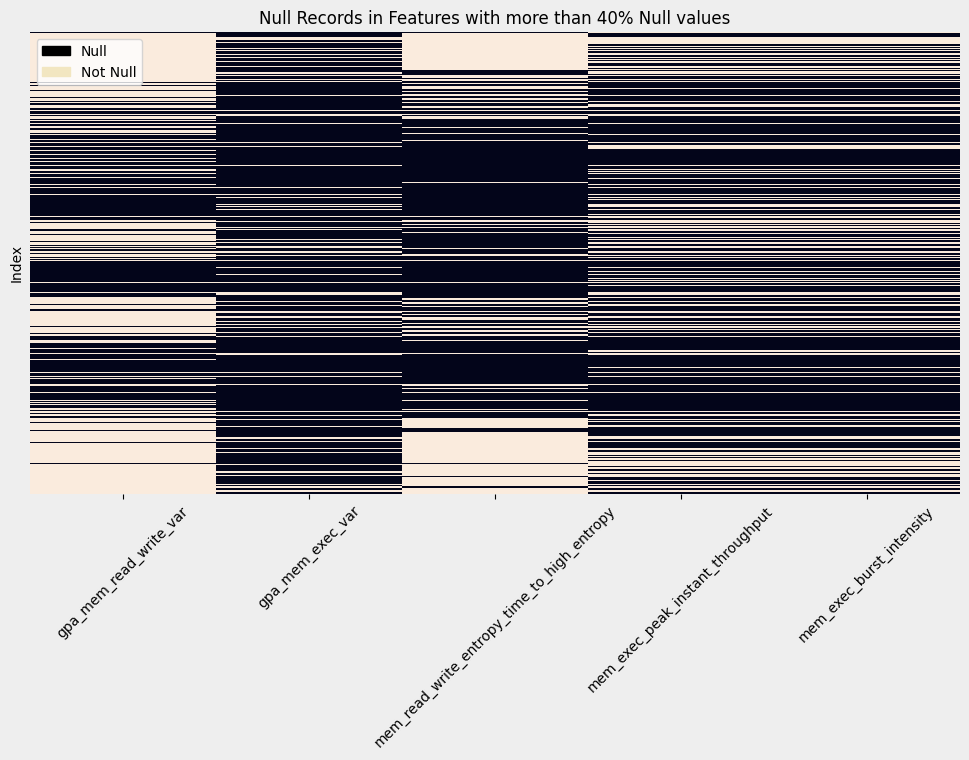

In [65]:
# plt.gcf().set_facecolor("#eeeeeeff")
null_threshold = 40
plt.figure(figsize=(12,6))
plt.gcf().set_facecolor("#eeeeeeff")
sns.heatmap(df[df[df.columns[df.isna().sum() > len(df)*(null_threshold/100)]].isna().sum().index].notnull(), cbar=False)
plt.yticks([])
plt.ylabel("Index")
plt.xticks(rotation=45)

null_patch = mpatches.Patch(color='black', label='Null')
not_null_patch = mpatches.Patch(color='#f2e6c1', label='Not Null')
plt.legend(handles=[null_patch, not_null_patch], loc='upper left')

plt.title(f"Null Records in Features with more than {null_threshold}% Null values");

## Feature Distribution

### Boxplots

C:\Users\malio\AppData\Local\Temp\ipykernel_129904\1020017383.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_ransomware', y='avg_ata_write', data=df, palette=ransomware_colors_dict);


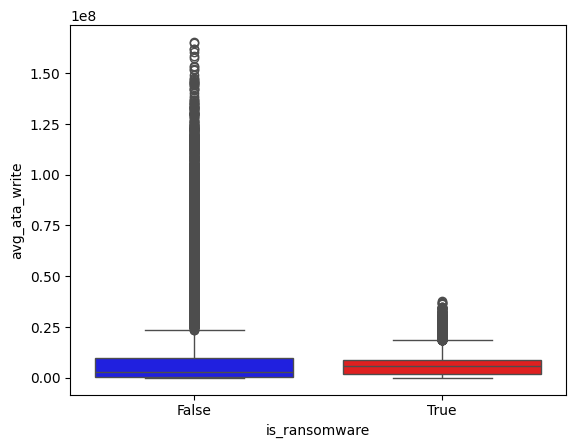

In [29]:
sns.boxplot(x='is_ransomware', y='avg_ata_write', data=df, palette=ransomware_colors_dict);

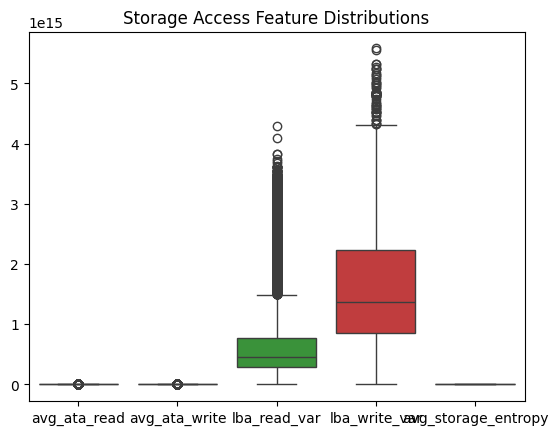

In [96]:
storage_feats = ['avg_ata_read', 'avg_ata_write', 'lba_read_var', 'lba_write_var', 'avg_storage_entropy']
mem_feats = [c for c in df.columns if 'mem_' in c and 'is_ransomware' not in c]

sns.boxplot(data=df[storage_feats])
plt.title('Storage Access Feature Distributions');

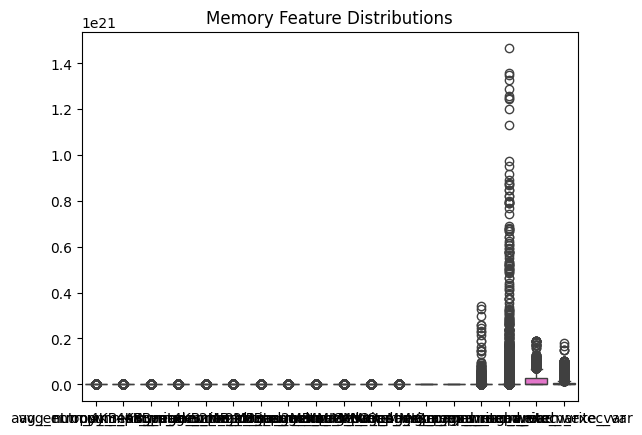

In [67]:
sns.boxplot(data=df[mem_feats])
plt.title('Memory Feature Distributions');

C:\Users\malio\AppData\Local\Temp\ipykernel_129904\3655412075.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='is_ransomware', y='avg_entropy_mem_write', data=df, palette=ransomware_colors_dict);


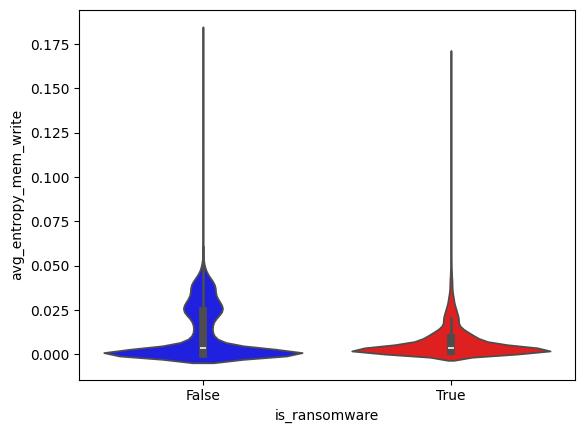

In [23]:
sns.violinplot(x='is_ransomware', y='avg_entropy_mem_write', data=df, palette=ransomware_colors_dict);

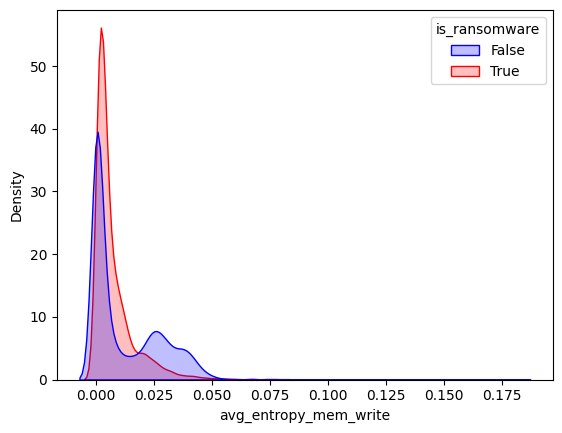

In [32]:
sns.kdeplot(data=df, x='avg_entropy_mem_write', hue='is_ransomware', fill=True, palette=ransomware_colors_dict);

### Skewness & Kurtosis

In [9]:
df_num_features = df.drop(columns=['is_ransomware', 'operation', 'operation_log_cnt', 'start_s', 'end_s'])
df_wo_null = df_num_features.dropna()

# skew, kurtosis cant be calculated using Null values so null values are dropped during the calculation
feature_stats = pd.DataFrame({
    'feature': df_num_features.columns.to_list(),
    'mean': np.mean(df_num_features, axis=0).to_list(),
    'variance': np.var(df_num_features, axis=0).to_list(),
    'skewness': skew(df_wo_null, axis=0),
    'kurtosis': kurtosis(df_wo_null, axis=0)
})

feature_stats.set_index('feature', inplace=True)

del df_wo_null

In [10]:
feature_stats

,mean,variance,skewness,kurtosis
feature,,,,
avg_ata_read,4.854942e+06,2.548964e+13,0.747237,0.711659
avg_ata_write,1.022412e+07,4.081371e+14,3.003894,16.876027
lba_read_var,6.502270e+14,3.480946e+29,3.939036,18.783964
lba_write_var,1.562234e+15,7.765991e+29,0.246359,-0.666989
avg_storage_entropy,5.943043e-01,6.223095e-02,-0.945563,-0.635829
...,...,...,...,...
mem_exec_avg_gpa_jump,2.915591e+08,1.633820e+18,2.711317,9.357818
mem_exec_max_gpa_jump,6.812296e+08,7.691273e+18,1.778607,1.870570
mem_exec_access_locality,3.095387e-01,2.071579e-01,-2.418356,5.114432


### Histograms

In [ ]:
def hist_continuous_vs_target(df, feature, target="is_ransomware", bins=40):
    plt.figure(figsize=(6,4))
    # plt.gcf().set_facecolor("#eeeeeeff")
    for cls, color in zip(sorted(df[target].unique()), ransomware_colors):
        vals = df.loc[df[target]==cls, feature].dropna()
        plt.hist(vals, bins=bins, alpha=0.6, density=True,
                 label=f"{target}={cls}", color=color)
    plt.title(f"{feature} distribution by {target}")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.legend(handles=[ransomware_patch, benign_patch])
    # plt.legend()
    plt.tight_layout()
    plt.show()


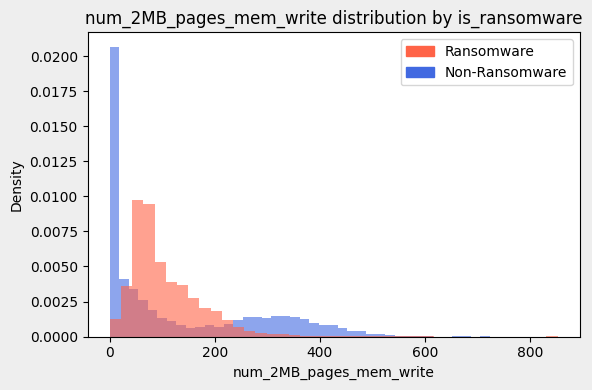

In [12]:
hist_continuous_vs_target(df, "num_2MB_pages_mem_write")

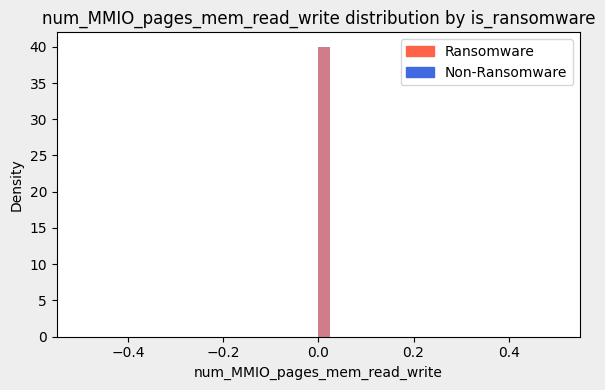

In [13]:
hist_continuous_vs_target(df, "num_MMIO_pages_mem_read_write")

## Storage vs Memory Pattern Analysis

In [58]:
df.columns

Index(['avg_ata_read', 'avg_ata_write', 'lba_read_var', 'lba_write_var',
       'avg_storage_entropy', 'avg_entropy_mem_write',
       'avg_entropy_mem_read_write', 'num_4KB_pages_mem_read',
       'num_4KB_pages_mem_write', 'num_4KB_pages_mem_read_write',
       'num_4KB_pages_mem_exec', 'num_2MB_pages_mem_read',
       'num_2MB_pages_mem_write', 'num_2MB_pages_mem_read_write',
       'num_2MB_pages_mem_exec', 'num_MMIO_pages_mem_read',
       'num_MMIO_pages_mem_write', 'num_MMIO_pages_mem_read_write',
       'num_MMIO_pages_mem_exec', 'gpa_mem_read_var', 'gpa_mem_write_var',
       'gpa_mem_read_write_var', 'gpa_mem_exec_var', 'is_ransomware',
       'operation', 'operation_log_cnt', 'start_s', 'end_s'],
      dtype='object')

## Entropy Based Feature Insights

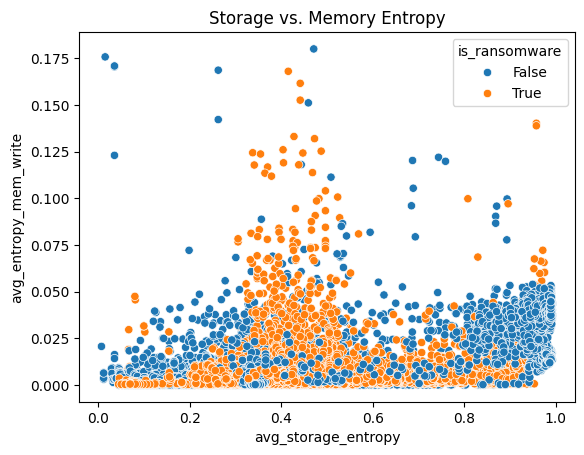

In [7]:
sns.scatterplot(x='avg_storage_entropy', y='avg_entropy_mem_write', hue='is_ransomware', data=df)
plt.title('Storage vs. Memory Entropy');

<Axes: >

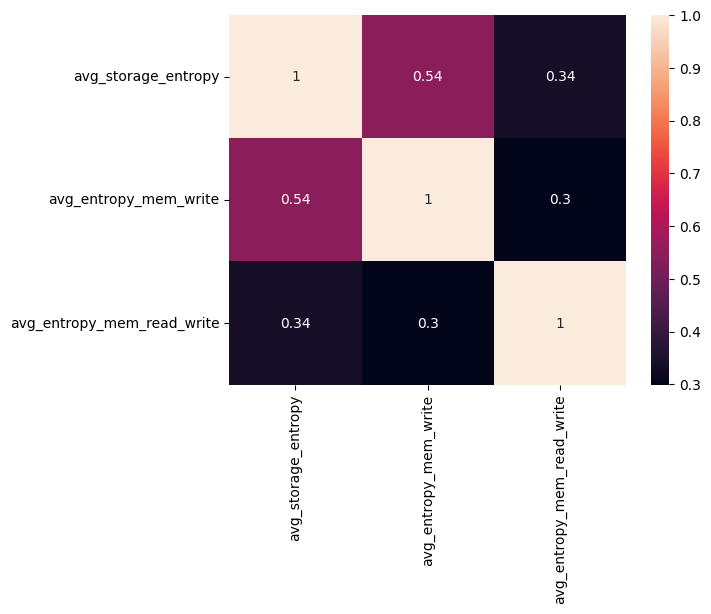

In [8]:
sns.heatmap(df[['avg_storage_entropy', 'avg_entropy_mem_write', 'avg_entropy_mem_read_write']].corr(), annot=True)

C:\Users\malio\AppData\Local\Temp\ipykernel_70724\4070726952.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(['Benign', 'Ransomware'])
C:\Users\malio\AppData\Local\Temp\ipykernel_70724\4070726952.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(['Benign', 'Ransomware'])
C:\Users\malio\AppData\Local\Temp\ipykernel_70724\4070726952.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(['Benign', 'Ransomware'])


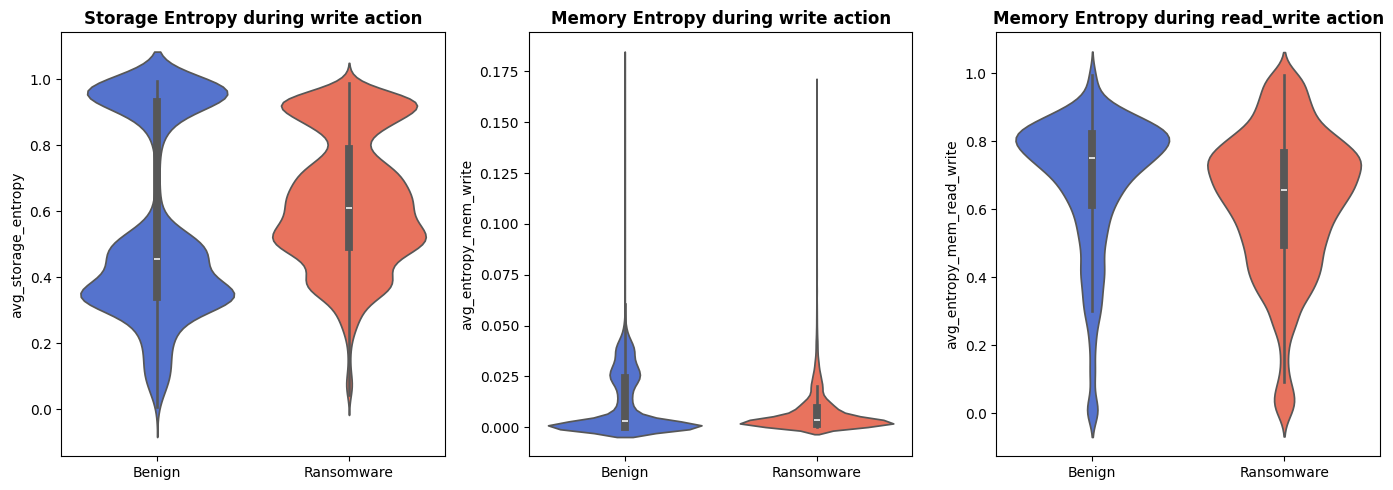

In [ ]:
# Memory entropy comparison
memory_entropy_features = ['avg_storage_entropy', 'avg_entropy_mem_write', 'avg_entropy_mem_read_write']
plot_titles = ['Storage Entropy during write action', 'Memory Entropy during write action', 'Memory Entropy during read_write action']
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for idx, feature in enumerate(memory_entropy_features):
    # Violin plot
    sns.violinplot(data=df, x='is_ransomware', y=feature, ax=axes[idx],
                   palette=ransomware_colors_dict, inner='box', hue='is_ransomware')
    axes[idx].set_title(f'{plot_titles[idx]}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_xticklabels(['Benign', 'Ransomware'])
    legend = axes[idx].legend()
    legend.remove()
    
plt.tight_layout()
plt.show()
del plot_titles

## Page-Level Feature Behavior

In [ ]:
mem_page_cols_dict = {
    '4KiB':['num_4KB_pages_mem_read', 'num_4KB_pages_mem_write', 'num_4KB_pages_mem_read_write', 'num_4KB_pages_mem_exec'],
    '2MiB': ['num_2MB_pages_mem_read', 'num_2MB_pages_mem_write', 'num_2MB_pages_mem_read_write', 'num_2MB_pages_mem_exec'],
    'MMIO': ['num_MMIO_pages_mem_read', 'num_MMIO_pages_mem_write', 'num_MMIO_pages_mem_read_write', 'num_MMIO_pages_mem_exec']
    }

mem_page_cols_arr = [col for subcol in list(mem_page_cols_dict.values()) for col in subcol]

memory_page_by_ransomware = df.groupby('is_ransomware')[mem_page_cols_arr].mean()
memory_page_by_ransomware.columns

Index(['num_4KB_pages_mem_read', 'num_4KB_pages_mem_write',
       'num_4KB_pages_mem_read_write', 'num_4KB_pages_mem_exec',
       'num_2MB_pages_mem_read', 'num_2MB_pages_mem_write',
       'num_2MB_pages_mem_read_write', 'num_2MB_pages_mem_exec',
       'num_MMIO_pages_mem_read', 'num_MMIO_pages_mem_write',
       'num_MMIO_pages_mem_read_write', 'num_MMIO_pages_mem_exec'],
      dtype='object')

In [16]:
memory_page_by_ransomware = memory_page_by_ransomware.rename(columns=
    {
    'num_4KB_pages_mem_read': 'C_4KB_mem_read',
    'num_4KB_pages_mem_write': 'C_4KB_mem_write',
    'num_4KB_pages_mem_read_write': 'C_4KB_mem_read_write',
    'num_4KB_pages_mem_exec': 'C_4KB_mem_exec',
    'num_2MB_pages_mem_read': 'C_2MB_mem_read',
    'num_2MB_pages_mem_write': 'C_2MB_mem_write',
    'num_2MB_pages_mem_read_write': 'C_2MB_mem_read_write',
    'num_2MB_pages_mem_exec': 'C_2MB_mem_exec',
    'num_MMIO_pages_mem_read': 'C_MMIO_mem_read',
    'num_MMIO_pages_mem_write': 'C_MMIO_mem_write',
    'num_MMIO_pages_mem_read_write': 'C_MMIO_mem_read_write',
    'num_MMIO_pages_mem_exec': 'C_MMIO_mem_exec',
    })

new_mem_page_cols_dict = {'4KiB' : ['C_4KB_mem_read', 'C_4KB_mem_write', 'C_4KB_mem_read_write', 'C_4KB_mem_exec'], 
'2MiB': ['C_2MB_mem_read', 'C_2MB_mem_write', 'C_2MB_mem_read_write', 'C_2MB_mem_exec'], 
'MMIO':[ 'C_MMIO_mem_read', 'C_MMIO_mem_write', 'C_MMIO_mem_read_write', 'C_MMIO_mem_exec']}

In [22]:
memory_page_by_ransomware[mem_page_cols_dict['4KiB']]

,num_4KB_pages_mem_read,num_4KB_pages_mem_write,num_4KB_pages_mem_read_write,num_4KB_pages_mem_exec
is_ransomware,,,,
False,1.380508,0.069474,0.024609,0.029584
True,1.090856,0.039708,0.046589,0.017823


C:\Users\malio\AppData\Local\Temp\ipykernel_18792\4031562938.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


Text(0.5, 0, 'Average Number of Memory Pages')

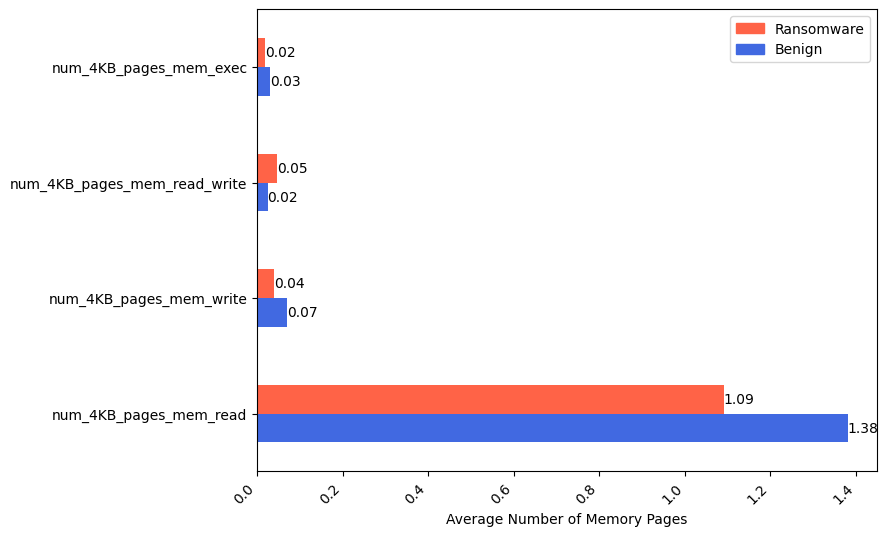

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
memory_page_by_ransomware[mem_page_cols_dict['4KiB']].T.plot(kind='barh', ax=ax, color=ransomware_colors)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(handles=[ransomware_patch, benign_patch])
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
ax.set_xlabel('Average Number of Memory Pages')

C:\Users\malio\AppData\Local\Temp\ipykernel_18792\2396740769.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


Text(0.5, 0, 'Average Number of Memory Pages')

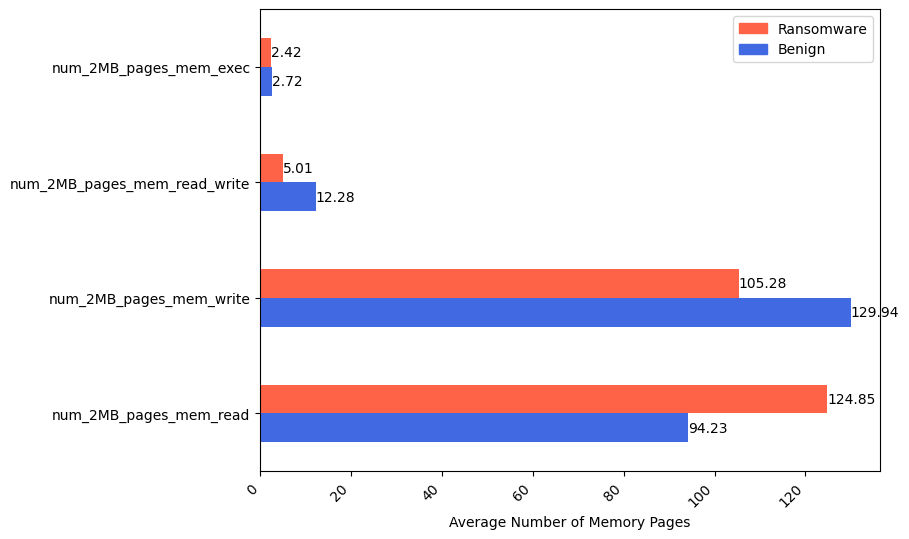

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
memory_page_by_ransomware[mem_page_cols_dict['2MiB']].T.plot(kind='barh', ax=ax, color=ransomware_colors)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(handles=[ransomware_patch, benign_patch])
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
ax.set_xlabel('Average Number of Memory Pages')

C:\Users\malio\AppData\Local\Temp\ipykernel_18792\1446861978.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


Text(0.5, 0, 'Average Number of Memory Pages')

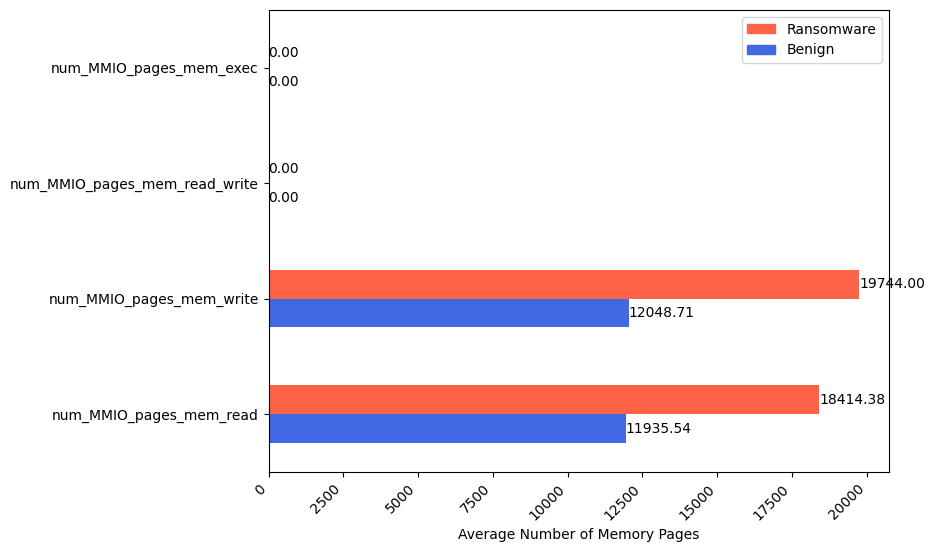

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
memory_page_by_ransomware[mem_page_cols_dict['MMIO']].T.plot(kind='barh', ax=ax, color=ransomware_colors)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(handles=[ransomware_patch, benign_patch])
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
ax.set_xlabel('Average Number of Memory Pages')

C:\Users\malio\AppData\Local\Temp\ipykernel_31312\3468728277.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')
C:\Users\malio\AppData\Local\Temp\ipykernel_31312\3468728277.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')
C:\Users\malio\AppData\Local\Temp\ipykernel_31312\3468728277.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')


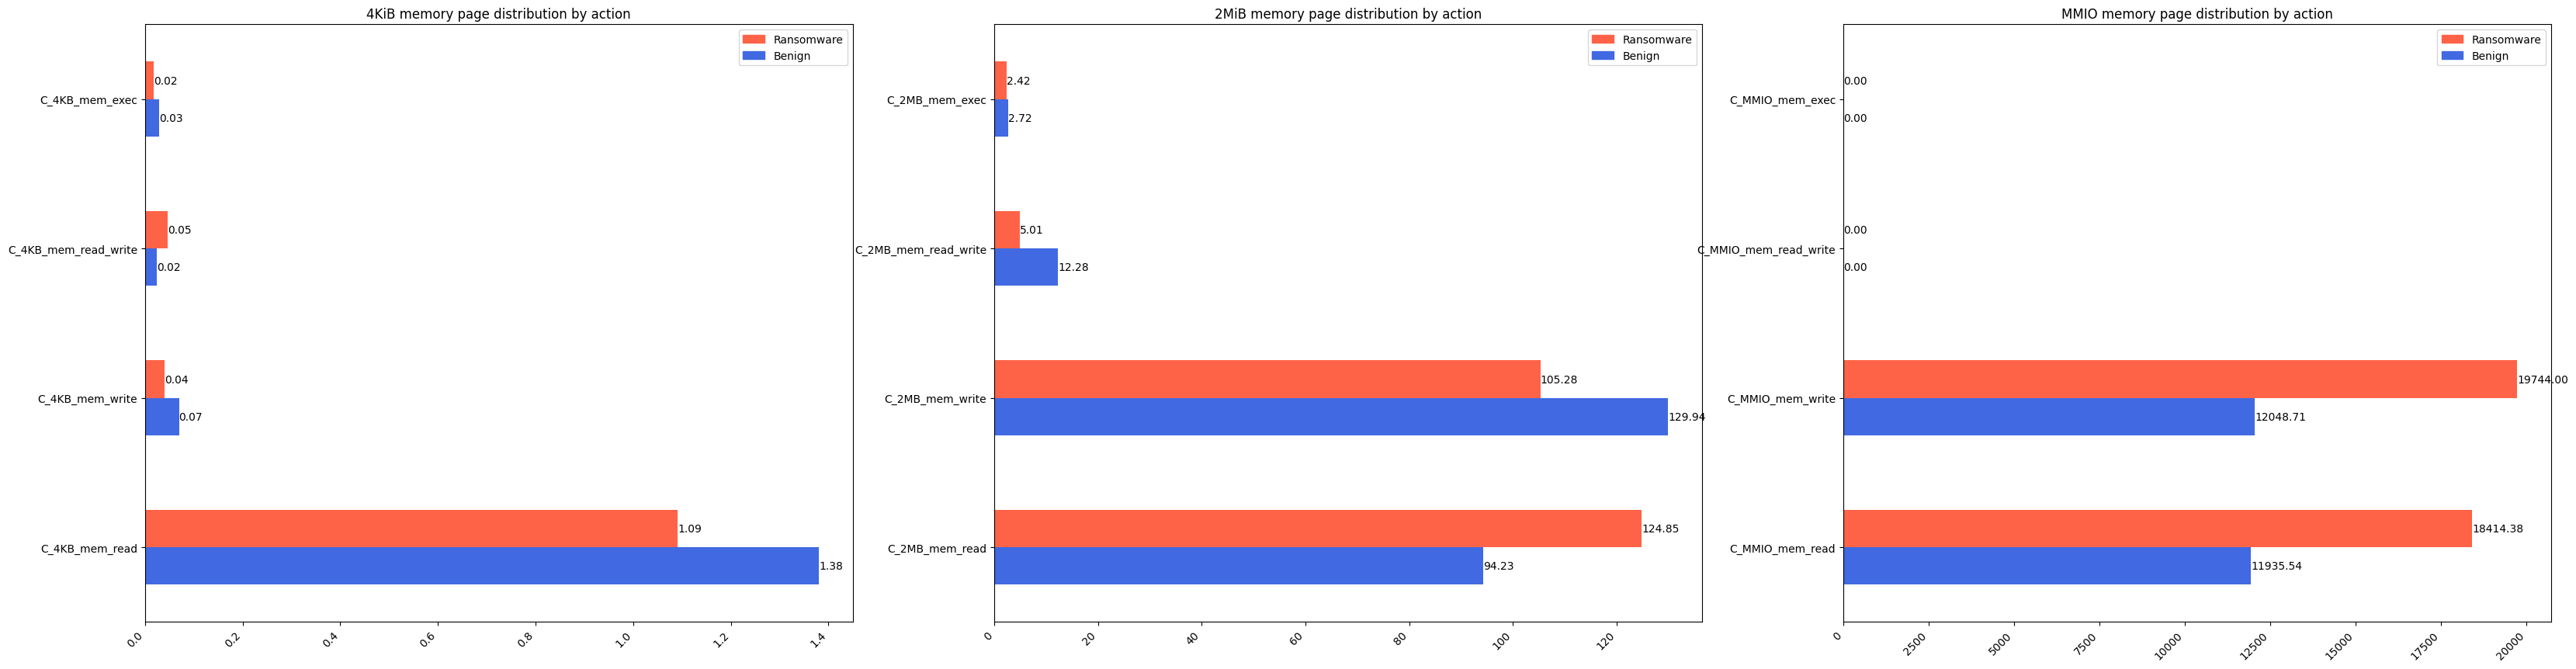

In [ ]:
fig, axes = plt.subplots(1, len(new_mem_page_cols_dict), figsize=(40, 10))

idx = 0
for mem_page, cols in new_mem_page_cols_dict.items():
    memory_page_by_ransomware[cols].T.plot(kind='barh', ax=axes[idx], color=ransomware_colors)
    axes[idx].set_title(f'{mem_page} memory page distribution by action')
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')
    axes[idx].legend(handles=[ransomware_patch, benign_patch])
    for container in axes[idx].containers:
        axes[idx].bar_label(container, fmt='%.2f')
        
    idx += 1


In [ ]:
def add_percentage_feature(df, value_column):
    total = df[value_column].sum()
    df[f'Percent_{value_column}'] = df[value_column] / total * 100
    
    return df

In [ ]:
# mem_page_cols = ['num_4KB_pages_mem_read', 'num_4KB_pages_mem_write', 'num_4KB_pages_mem_read_write', 'num_4KB_pages_mem_exec', 
# 'num_2MB_pages_mem_read', 'num_2MB_pages_mem_write', 'num_2MB_pages_mem_read_write', 'num_2MB_pages_mem_exec', 
# 'num_MMIO_pages_mem_read', 'num_MMIO_pages_mem_write', 'num_MMIO_pages_mem_read_write', 'num_MMIO_pages_mem_exec']

# memory_page_by_ransomware = df.groupby('is_ransomware')[mem_page_cols_arr].mean()
# memory_page_by_ransomware.columns

In [ ]:
# memory_page_by_ransomware.columns = ['4KB_mem_read', '4KB_mem_write', '4KB_mem_read_write', '4KB_mem_exec', 
# '2MB_mem_read', '2MB_mem_write', '2MB_mem_read_write', '2MB_mem_exec', 
# 'MMIO_mem_read', 'MMIO_mem_write', 'MMIO_mem_read_write', 'MMIO_mem_exec']

In [36]:
for column in memory_page_by_ransomware.columns:
    memory_page_by_ransomware = add_percentage_feature(memory_page_by_ransomware, column)

In [18]:
memory_page_by_ransomware

,num_4KB_pages_mem_read,num_4KB_pages_mem_write,num_4KB_pages_mem_read_write,num_4KB_pages_mem_exec,num_2MB_pages_mem_read,num_2MB_pages_mem_write,num_2MB_pages_mem_read_write,num_2MB_pages_mem_exec,num_MMIO_pages_mem_read,num_MMIO_pages_mem_write,num_MMIO_pages_mem_read_write,num_MMIO_pages_mem_exec
is_ransomware,,,,,,,,,,,,
False,1.380508,0.069474,0.024609,0.029584,94.230366,129.940032,12.281361,2.723792,11935.535092,12048.711709,0.0,0.0
True,1.090856,0.039708,0.046589,0.017823,124.851032,105.280942,5.007792,2.421371,18414.384896,19744.004891,0.0,0.0


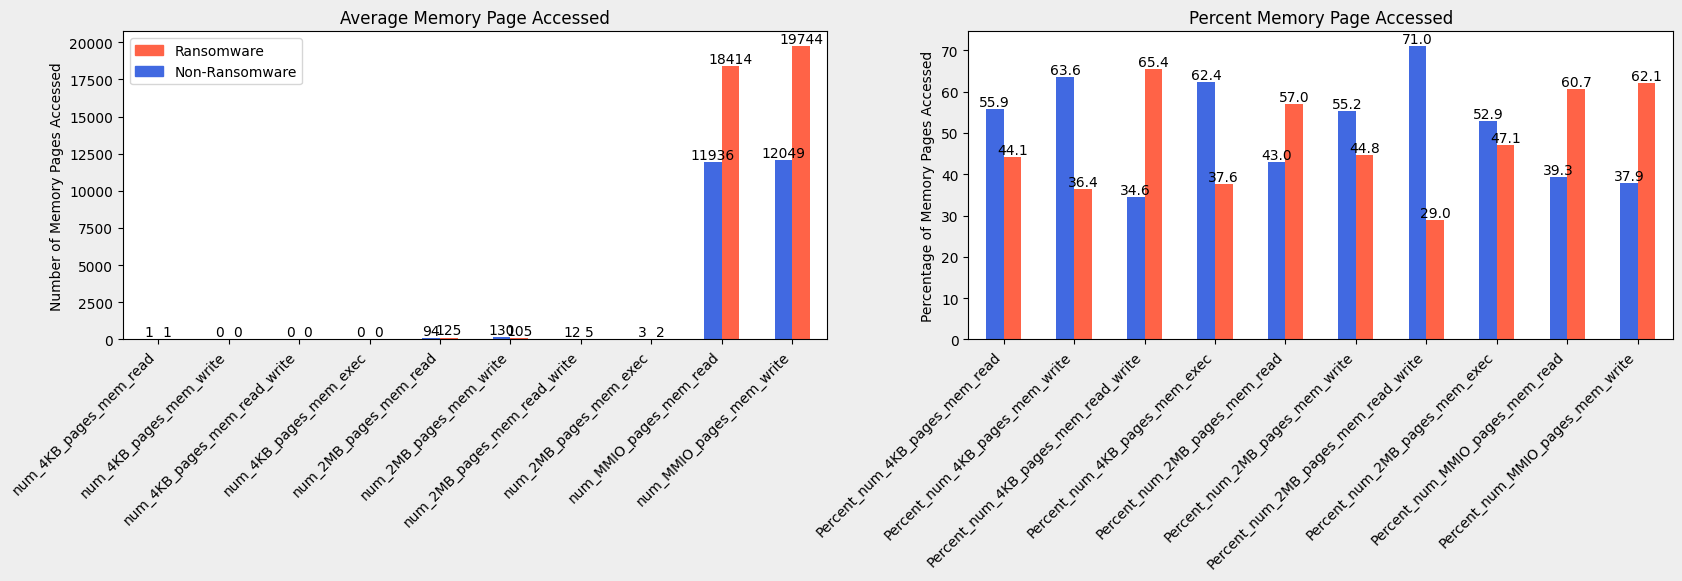

In [ ]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(20, 4))
plt.gcf().set_facecolor("#eeeeeeff")

memory_page_by_ransomware.iloc[:, :len(memory_page_by_ransomware.columns)//2 -2].T.plot(kind='bar', ax=ax1, color=ransomware_colors)
ax1.set_title('Average Memory Page Accessed')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.set_ylabel("Number of Memory Pages Accessed")
ax1.legend(handles=[ransomware_patch, benign_patch])

for container in ax1.containers:
    ax1.bar_label(container, fmt='%.0f')
    

memory_page_by_ransomware.iloc[:, len(memory_page_by_ransomware.columns)//2:-2].T.plot(kind='bar', ax=ax2, legend=False, color=ransomware_colors)
ax2.set_title('Percent Memory Page Accessed') 
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.set_ylabel("Percentage of Memory Pages Accessed")

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f')

## Variance Features (Volatility of Activity)

Text(0.5, 1.02, 'Variance Features by Class')

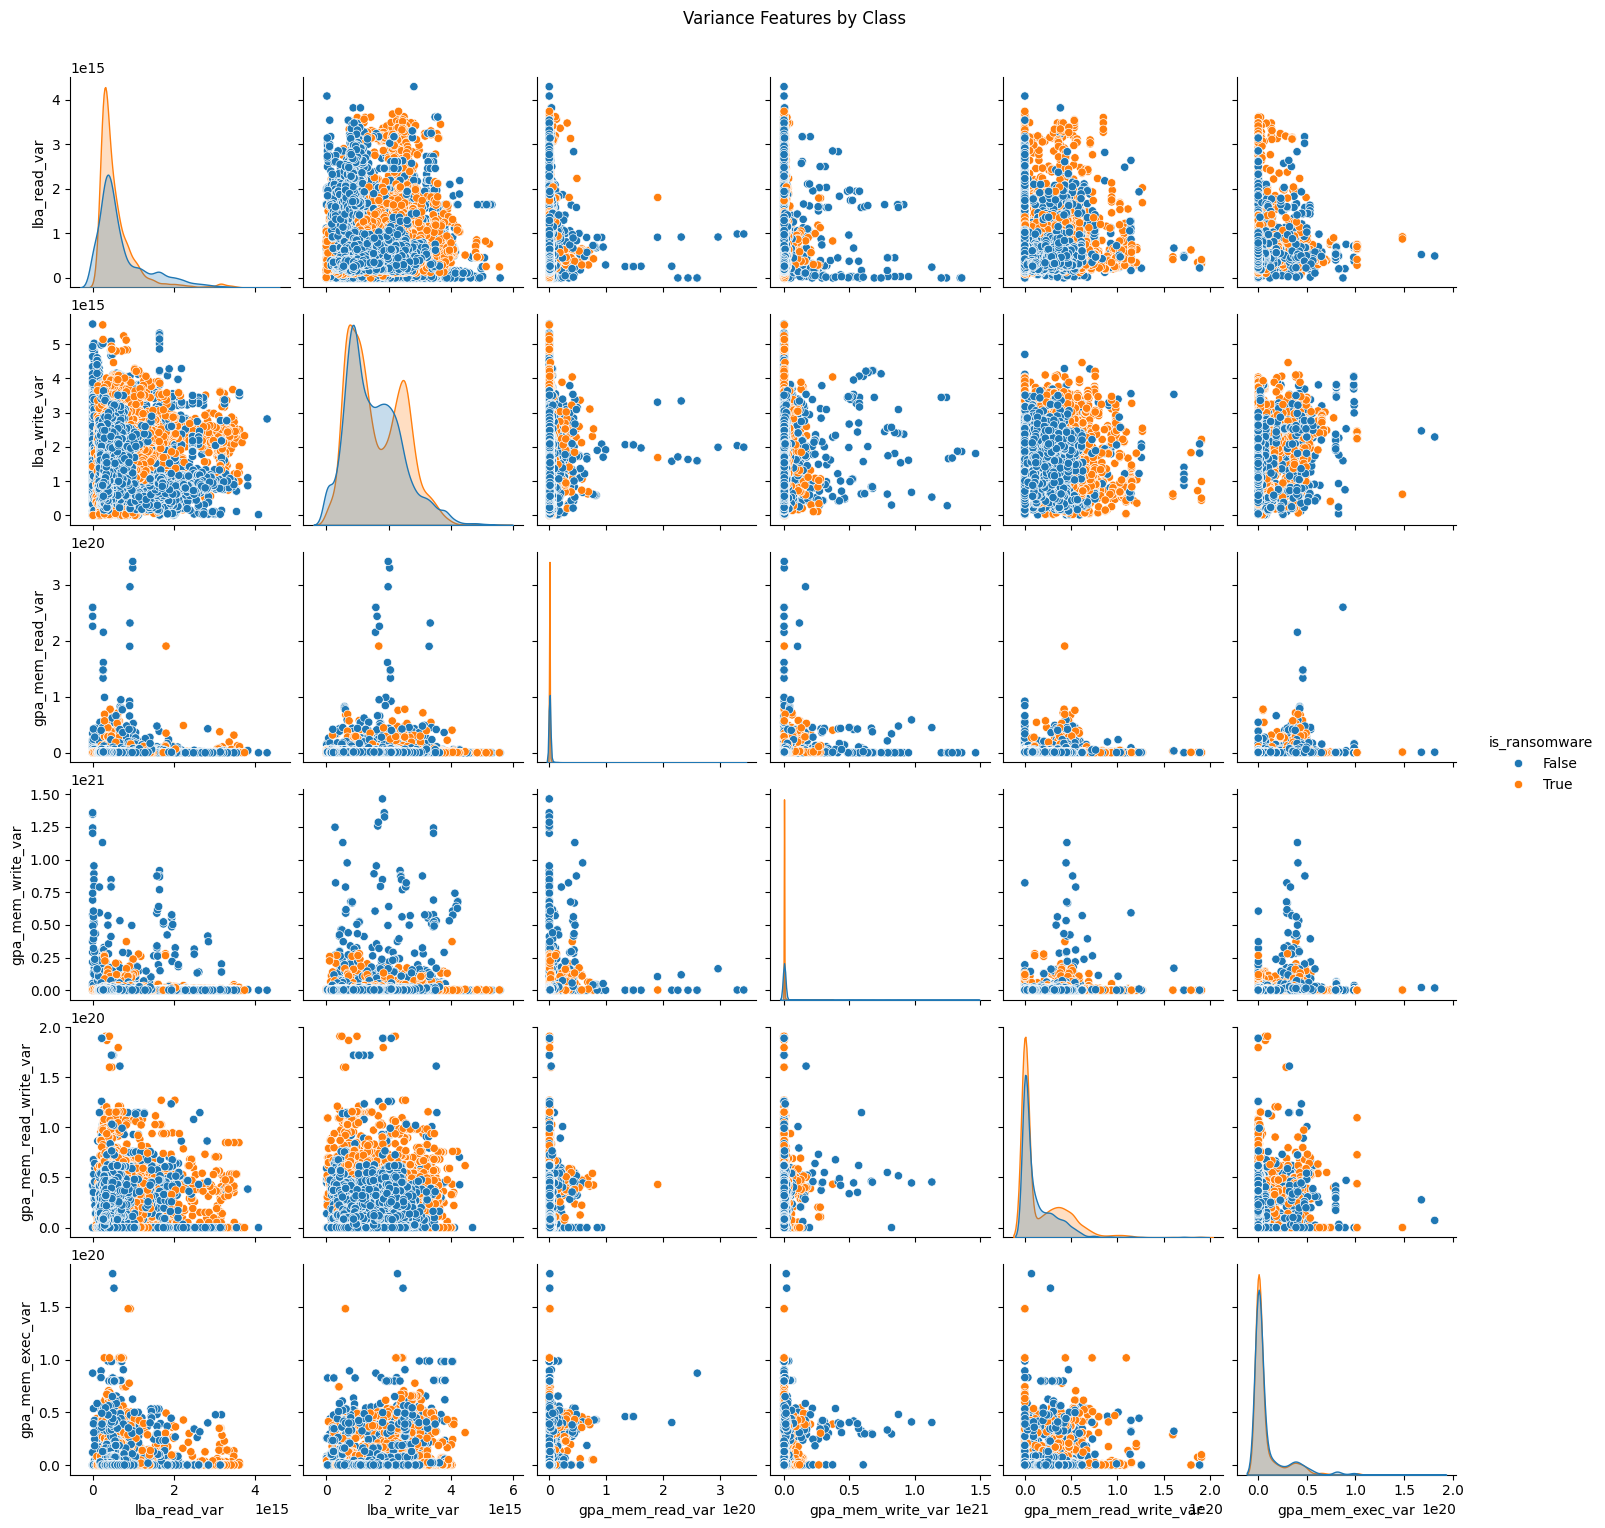

In [10]:
var_feats = ['lba_read_var', 'lba_write_var', 'gpa_mem_read_var', 'gpa_mem_write_var', 'gpa_mem_read_write_var', 'gpa_mem_exec_var']
sns.pairplot(df, vars=var_feats, hue='is_ransomware')
plt.suptitle('Variance Features by Class', y=1.02)

# Correlation Analysis

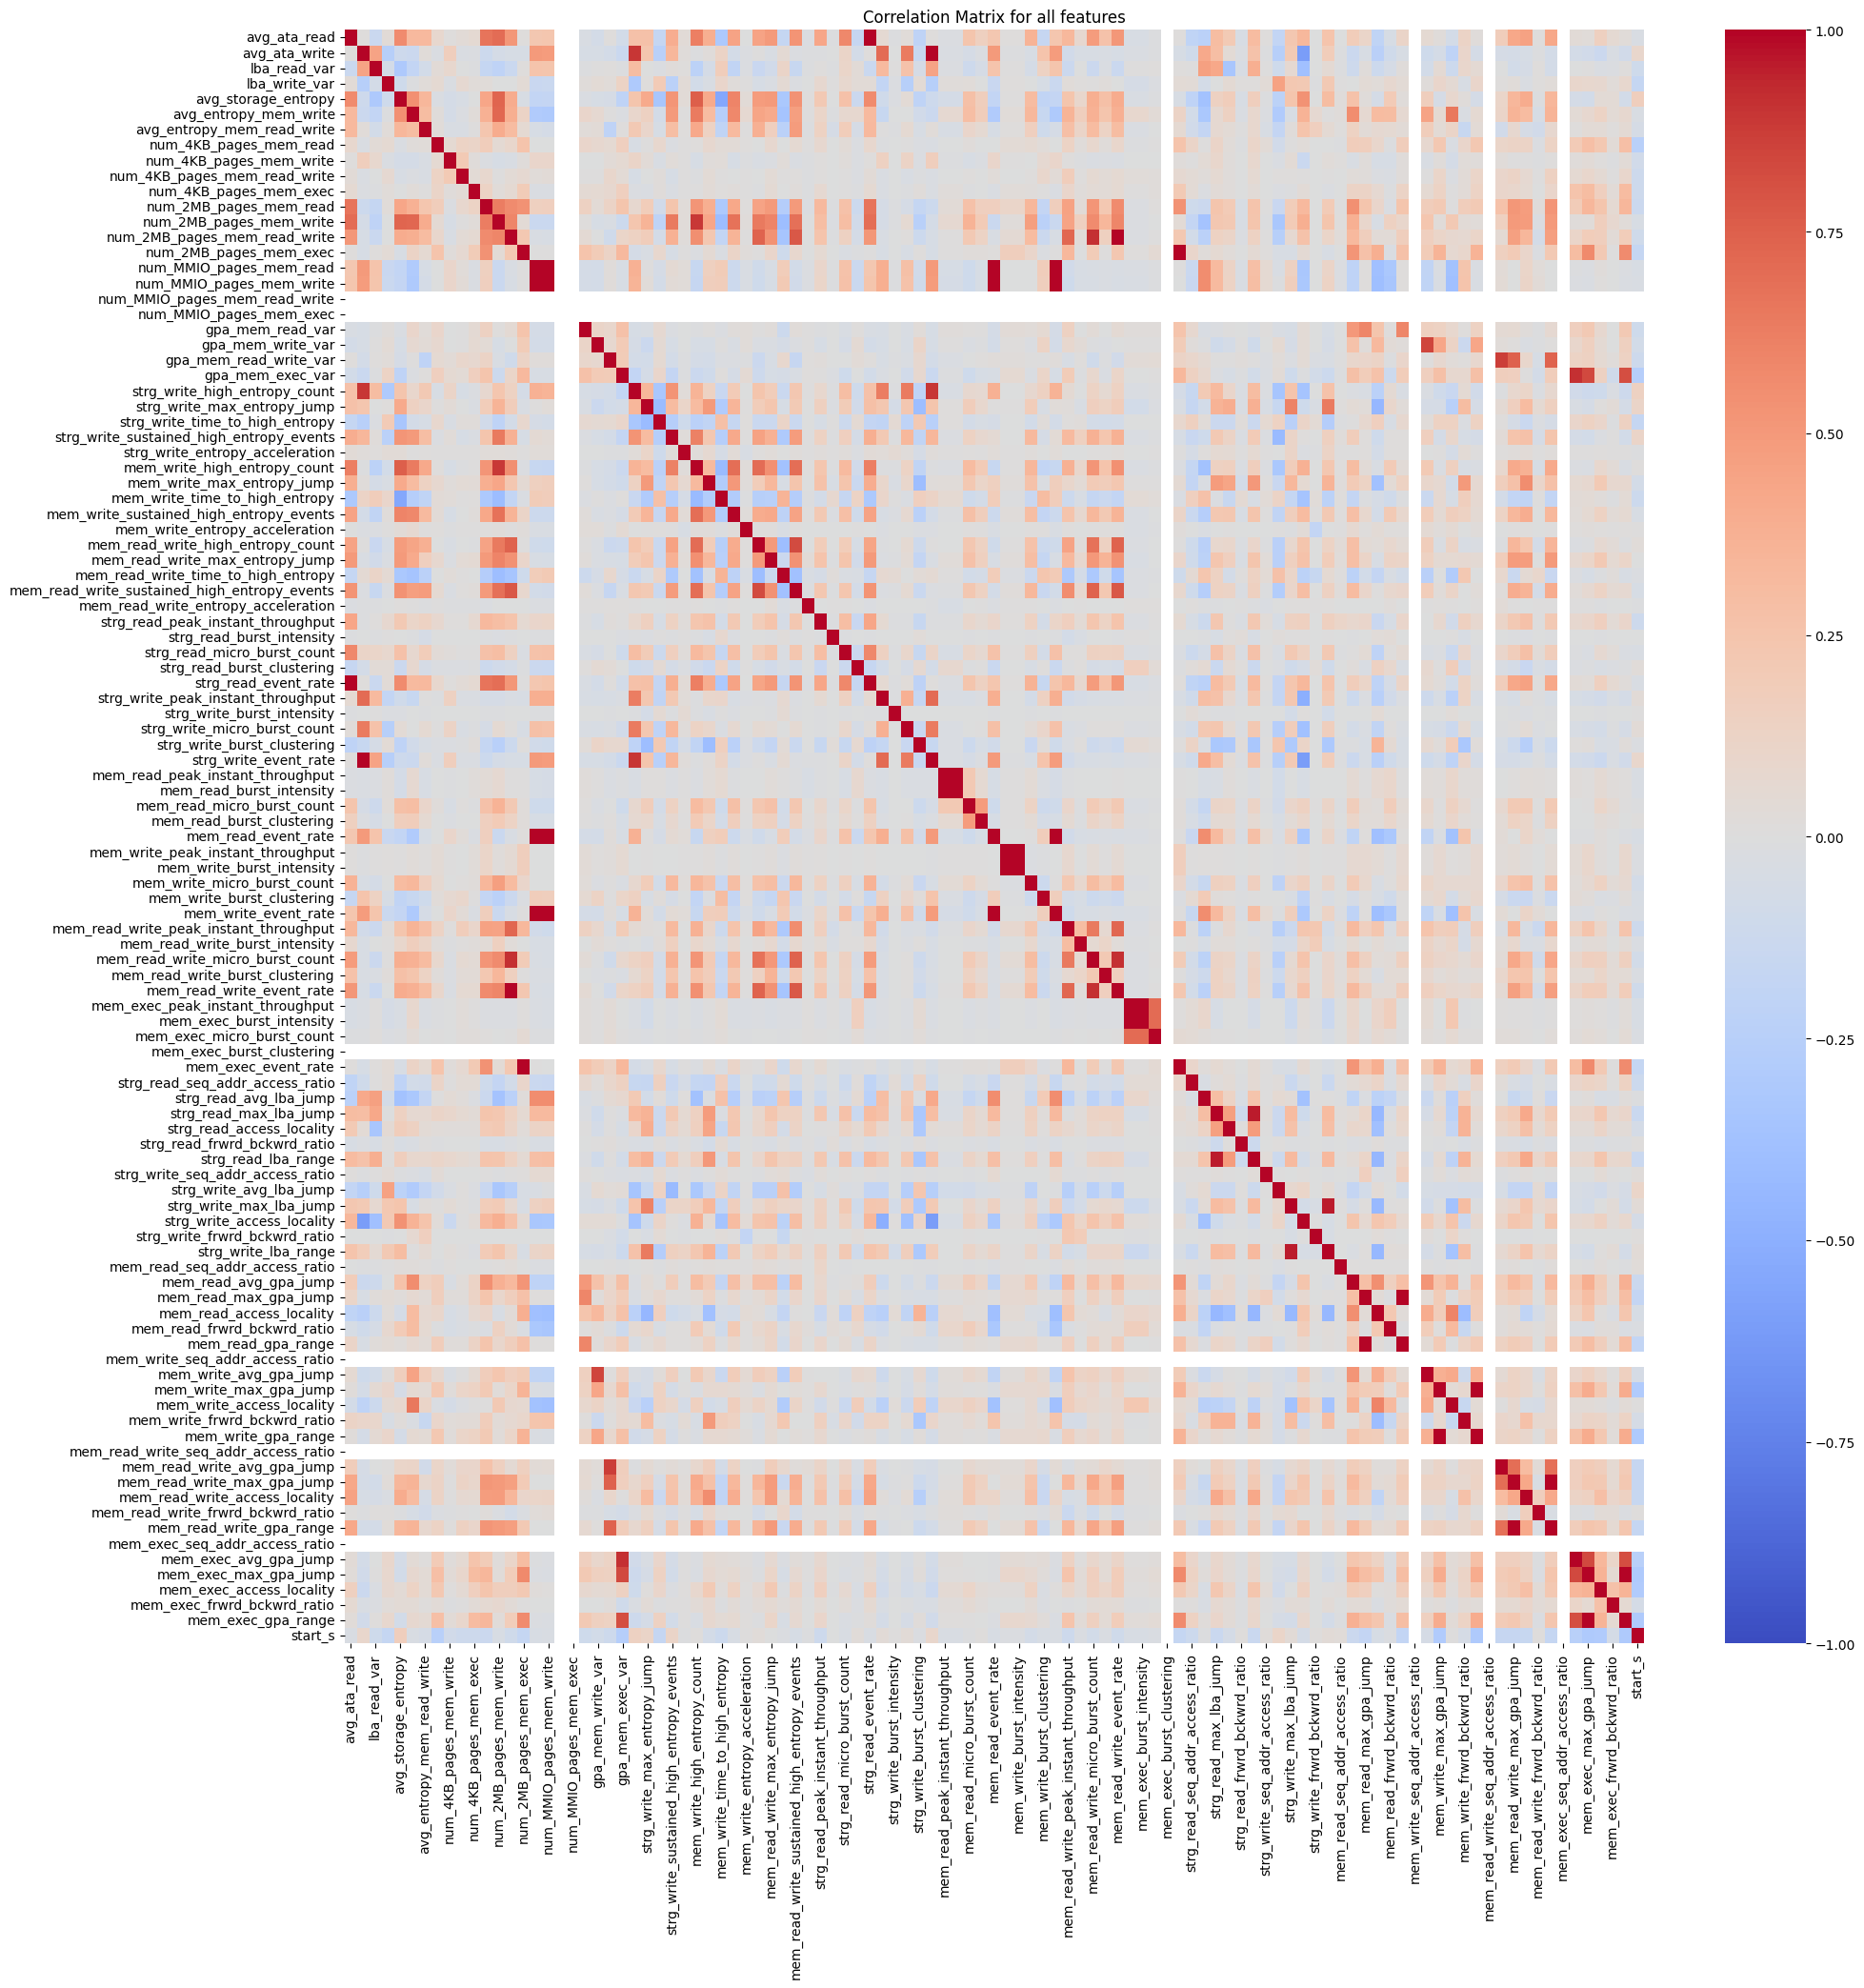

In [28]:
# Heatmap before null imputation
plt.figure(figsize=(22,22))
sns.heatmap(df.drop(columns=['is_ransomware', 'operation', 'operation_log_cnt', 'end_s']).corr(), cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title(f"Correlation Matrix for all features");

In [21]:
df_reduced = df.copy()

In [ ]:
corr_matrix = df_reduced.drop(columns=['is_ransomware', 'operation', 'operation_log_cnt']).corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

correlation_threshold = 0.9

high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'Feature_1', 'level_1': 'Feature_2', 0: 'Correlation'})
)

high_corr_pairs = high_corr_pairs[high_corr_pairs['Correlation'] > correlation_threshold]

high_correlated_features_with_pairs = set(high_corr_pairs['Feature_1'])
high_correlated_features_with_pairs.update(high_corr_pairs['Feature_2'])

to_drop_high_corr = [
    column for column in upper.columns if any(upper[column] > correlation_threshold)
]


print(f"Features to drop due to high correlation (> {correlation_threshold}):")
print(to_drop_high_corr)

Features to drop due to high correlation (> 0.9):
['num_MMIO_pages_mem_write', 'strg_read_event_rate', 'strg_write_event_rate', 'mem_read_burst_intensity', 'mem_read_event_rate', 'mem_write_burst_intensity', 'mem_write_event_rate', 'mem_read_write_micro_burst_count', 'mem_read_write_event_rate', 'mem_exec_burst_intensity', 'mem_exec_event_rate', 'strg_read_lba_range', 'strg_write_lba_range', 'mem_read_gpa_range', 'mem_write_gpa_range', 'mem_read_write_gpa_range', 'mem_exec_avg_gpa_jump', 'mem_exec_gpa_range', 'end_s']


In [23]:
corr_mat_features = list(high_correlated_features_with_pairs)
corr_mat_features.extend(["num_MMIO_pages_mem_read_write", "num_MMIO_pages_mem_exec"])

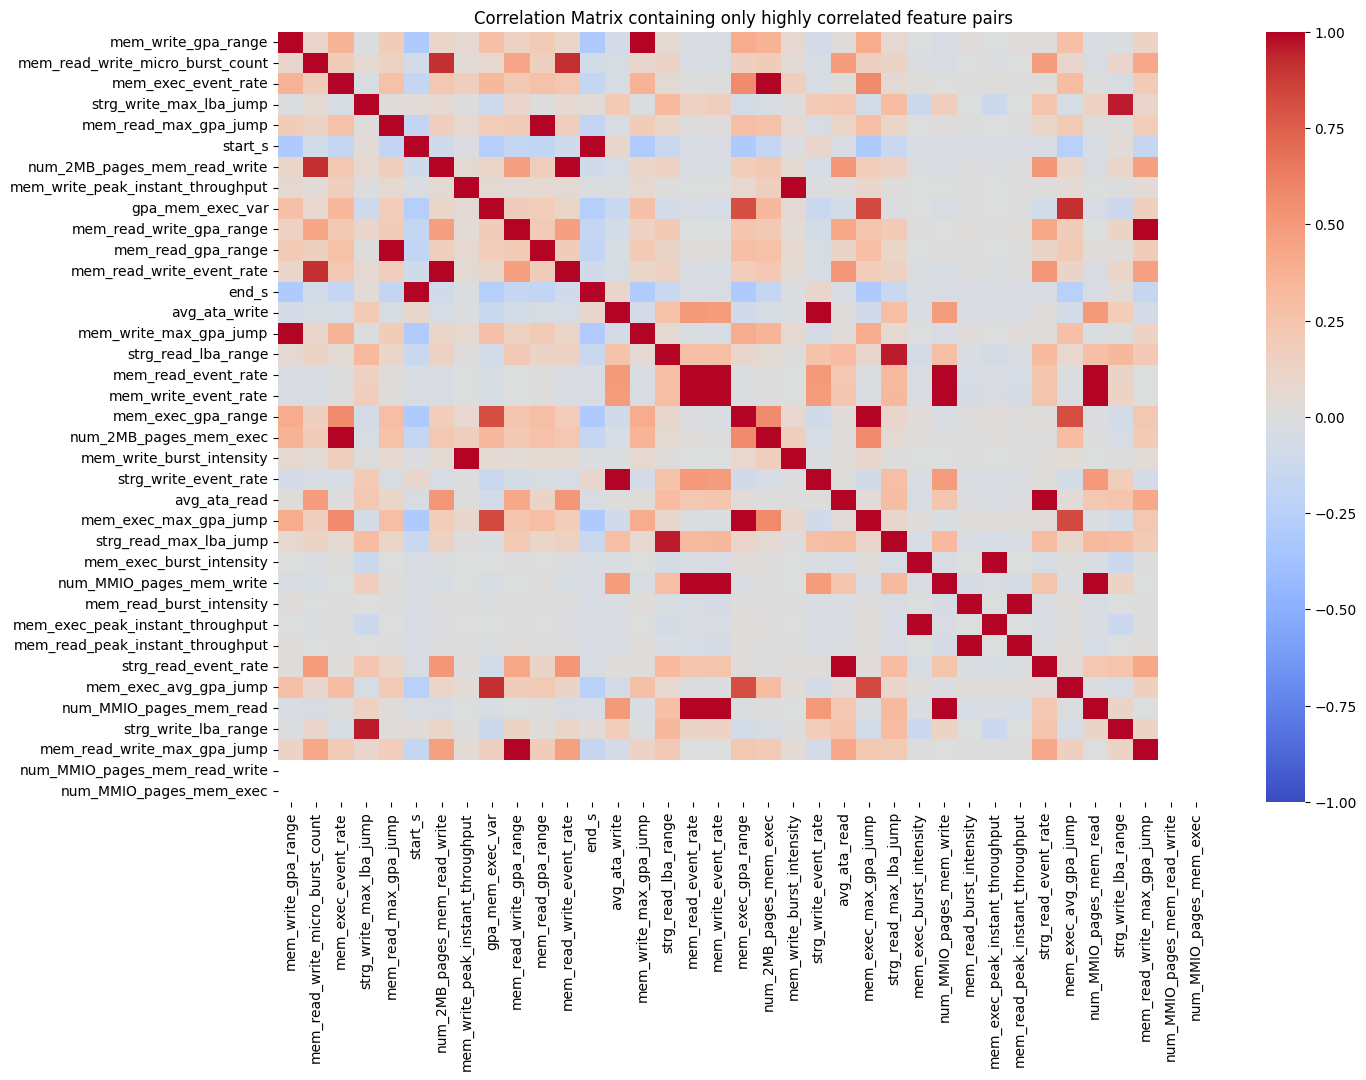

In [27]:
plt.figure(figsize=(15,10))
sns.heatmap(df_reduced[corr_mat_features].corr(), cmap='coolwarm', center=0, vmin=-1, vmax=1);
plt.title(f"Correlation Matrix containing only highly correlated feature pairs");

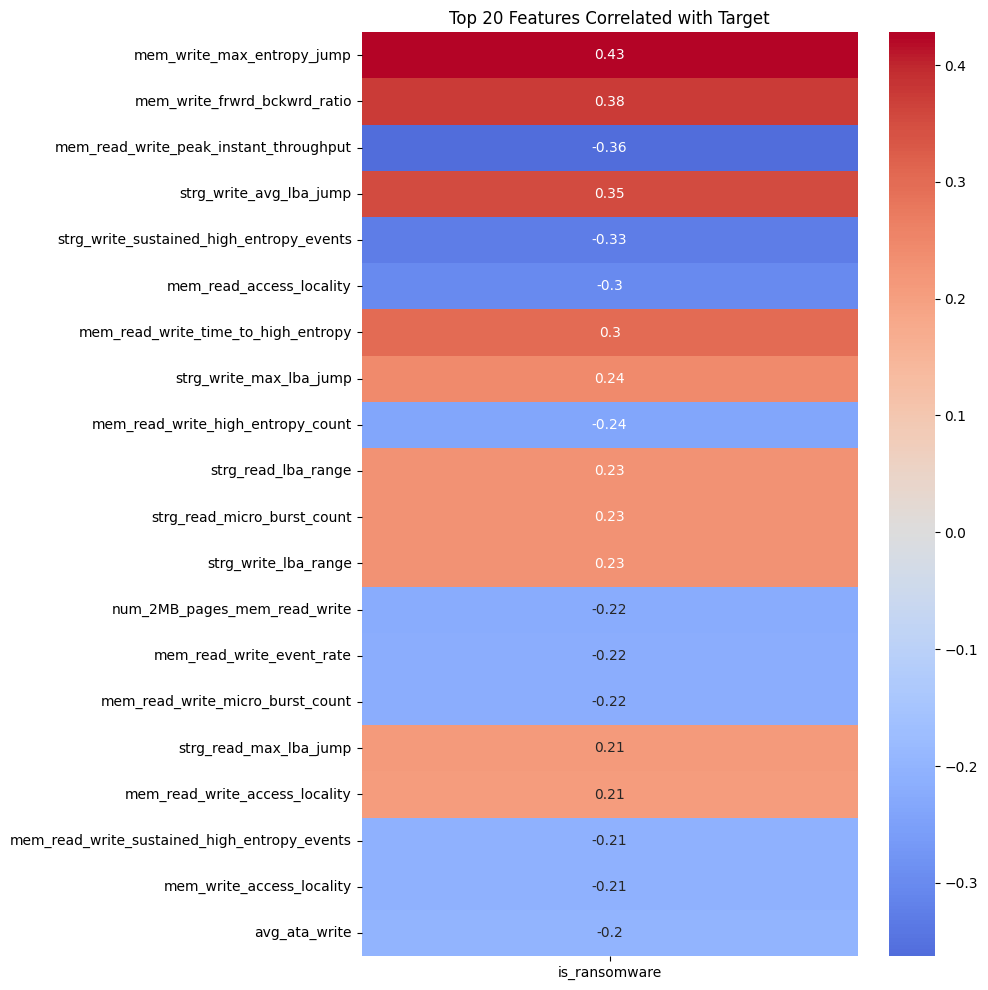

In [26]:
corr_with_target = df_reduced.drop(columns=['operation', 'operation_log_cnt']).corr(numeric_only=True)["is_ransomware"].drop("is_ransomware")
corr_sorted = corr_with_target.reindex(corr_with_target.abs().sort_values(ascending=False).index)

plt.figure(figsize=(8, 12))
sns.heatmap(corr_sorted[:20].to_frame(), annot=True, cmap="coolwarm", center=0)
plt.title("Top 20 Features Correlated with Target")
plt.show()

# Null Imputation

In [29]:
def timedelta_to_ns(t):
    if type(t) == pd.Timedelta:
        return t.total_seconds() * 1e9 + t.nanoseconds
    else:
        return t.total_seconds() * 1e9

In [33]:
df_imput = pd.read_pickle("processed_dataset/final_dataset_new_features_all_logs_10s_window.pkl")

In [ ]:

window_delta = df_imput.iloc[0]['end'] - df_imput.iloc[0]['start']
step_delta = df_imput[(df_imput['operation']=='AESCrypt') & (df_imput['operation_log_cnt']==1)]['start'].diff()[1]

time_to_high_entropy_cols = [col for col in df_imput.columns if 'time_to_high_entropy' in col]
# Fill null values in time cols with (window_size + step)
df_imput[time_to_high_entropy_cols] = df_imput[time_to_high_entropy_cols].fillna(timedelta_to_ns(window_delta+step_delta))
# Fill rest of nulls with zero as variance, mean, throughput, burst intensity are zero when no events take place in window
df_imput = df_imput.fillna(0)
df_imput = df_imput.drop(columns=['start', 'end'])

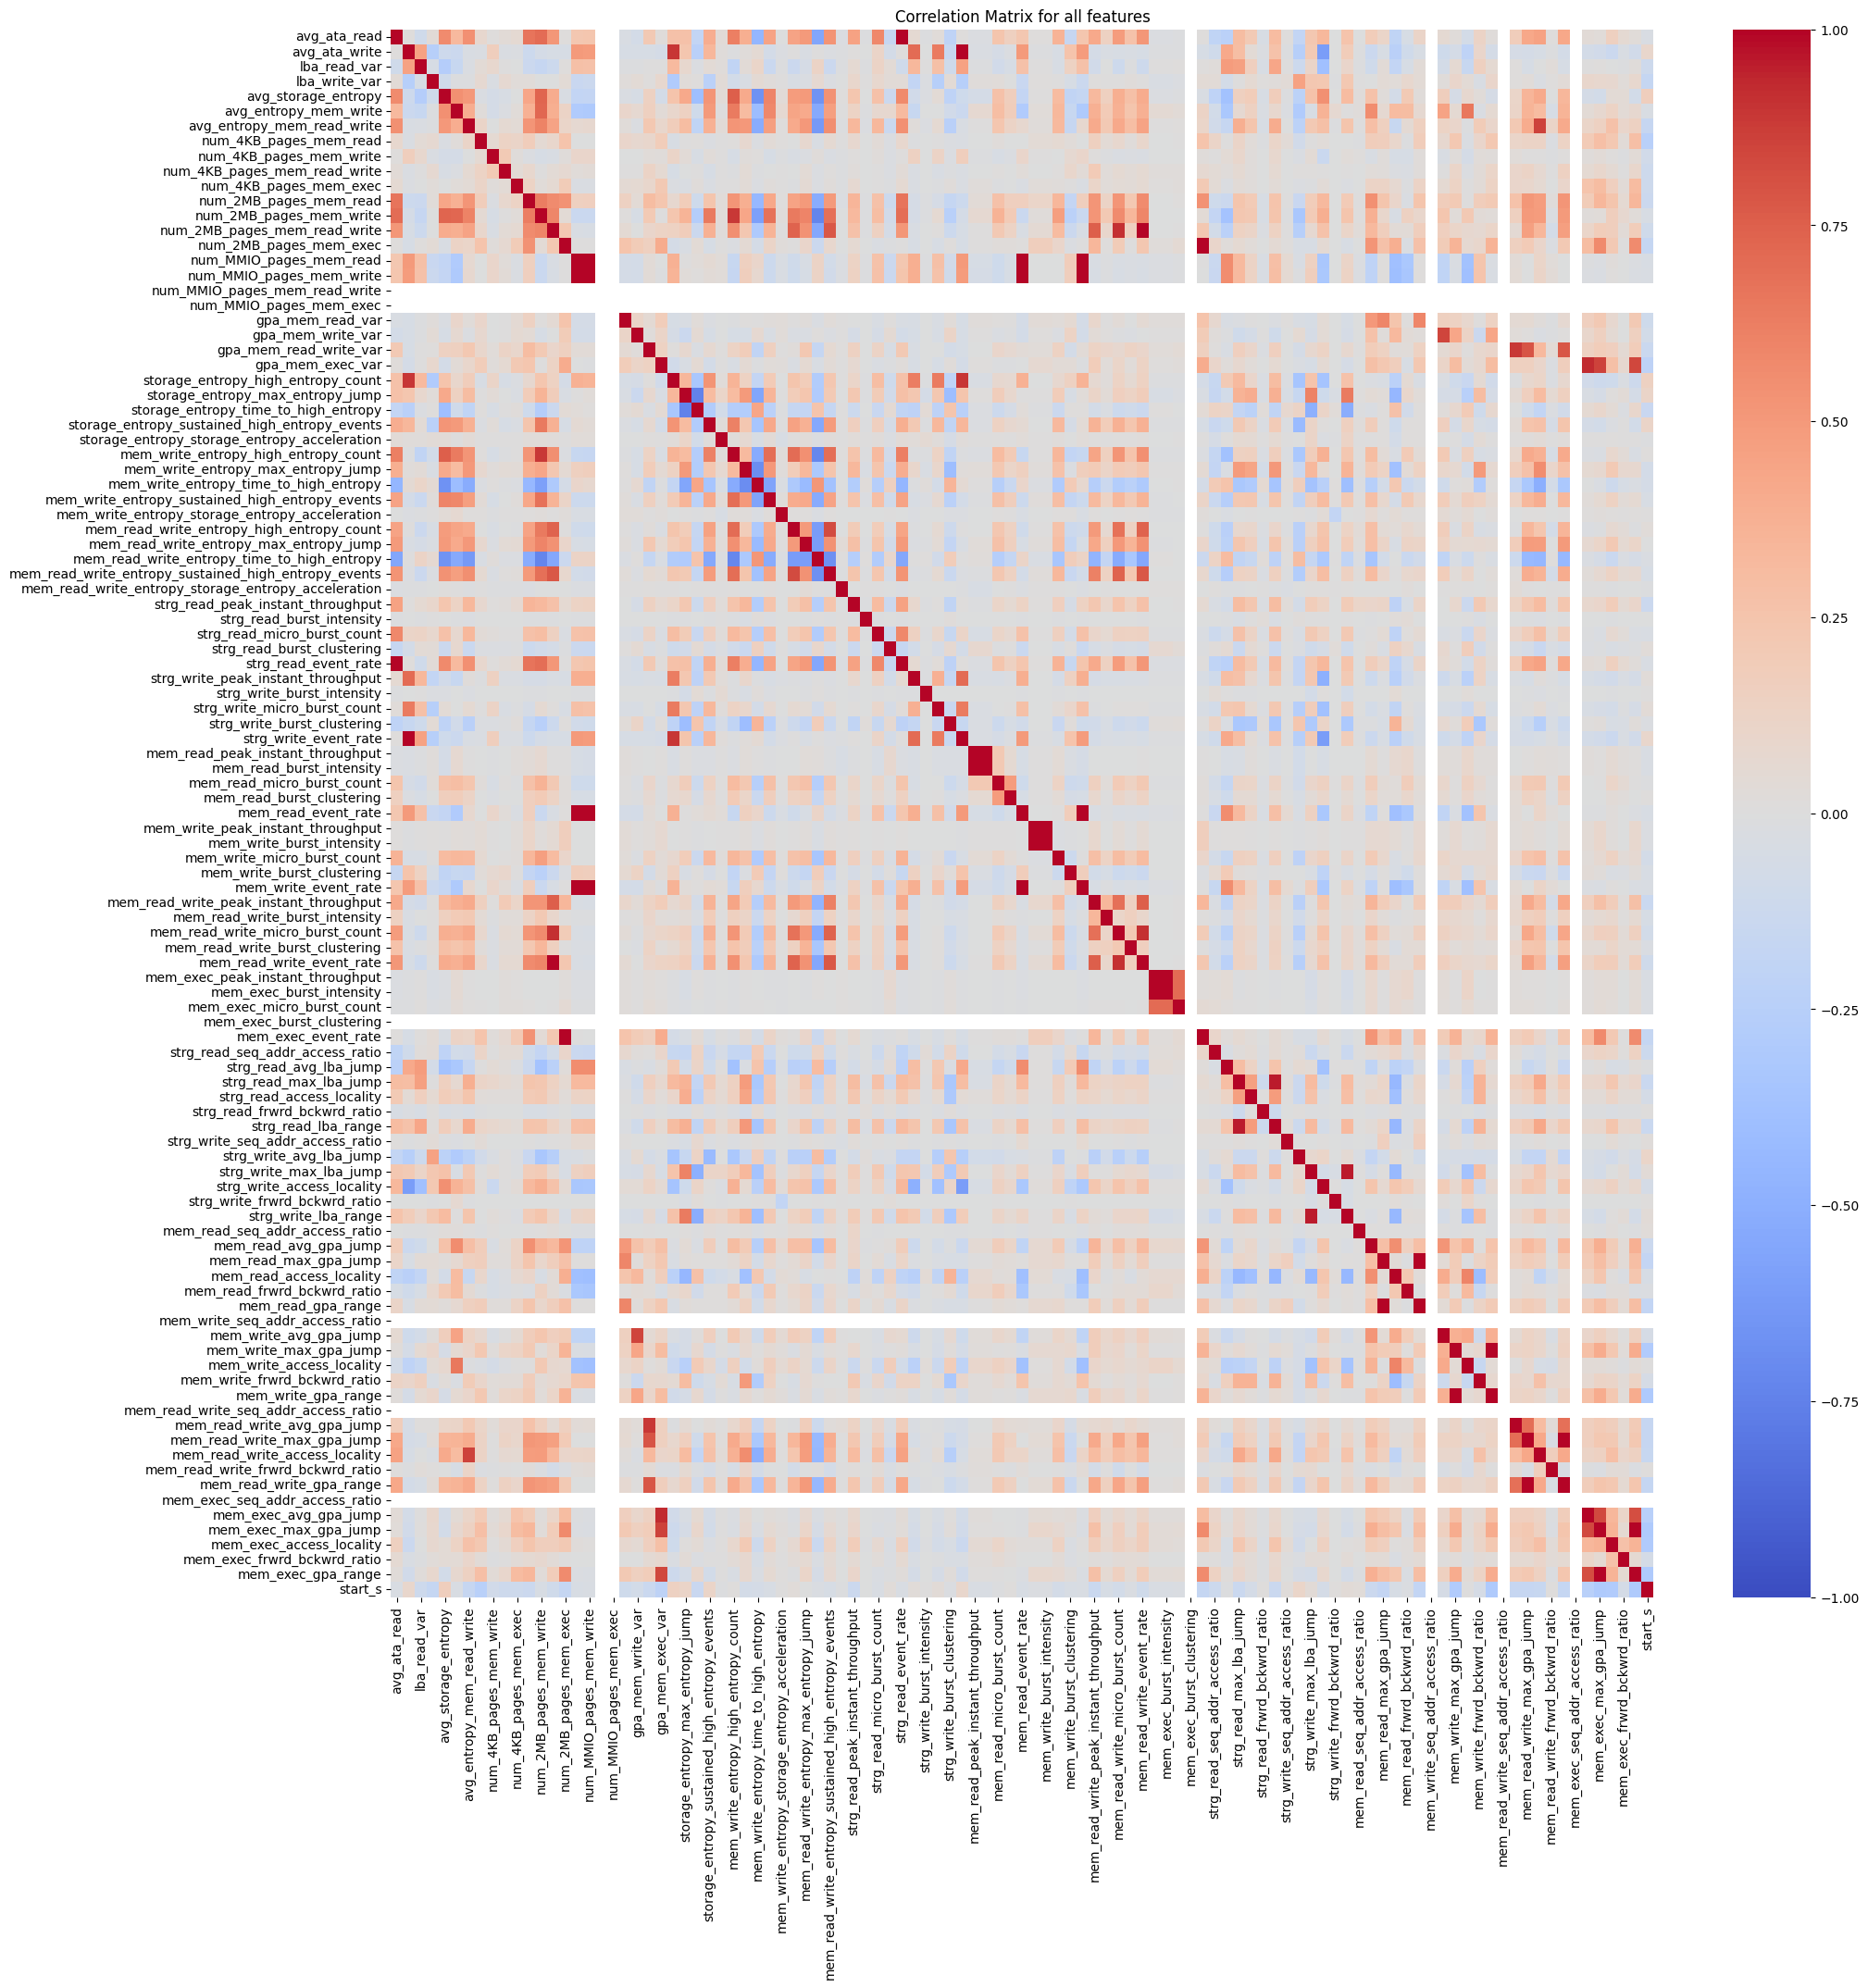

In [38]:
# Heatmap after null imputation
plt.figure(figsize=(22,22))
sns.heatmap(df_imput.drop(columns=['is_ransomware', 'operation', 'operation_log_cnt', 'end_s']).corr(), cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title(f"Correlation Matrix for all features");

In [47]:
df_imput[['num_MMIO_pages_mem_read_write', 'avg_ata_read', 'avg_ata_write', 'lba_read_var', 'lba_write_var', 'avg_storage_entropy']].corr()

,num_MMIO_pages_mem_read_write,avg_ata_read,avg_ata_write,lba_read_var,lba_write_var,avg_storage_entropy
num_MMIO_pages_mem_read_write,NaN,NaN,NaN,NaN,NaN,NaN
avg_ata_read,NaN,1.000000,0.010396,-0.094686,0.036821,0.570181
avg_ata_write,NaN,0.010396,1.000000,0.456177,-0.253374,-0.109422
lba_read_var,NaN,-0.094686,0.456177,1.000000,-0.053585,-0.270274
lba_write_var,NaN,0.036821,-0.253374,-0.053585,1.000000,-0.096234
avg_storage_entropy,NaN,0.570181,-0.109422,-0.270274,-0.096234,1.000000


In [ ]:
# Drop no correlation features
zero_var_cols = df_imput.drop(columns=['is_ransomware', 'operation', 'operation_log_cnt', 'end_s']).var() == 0
zero_var_cols = zero_var_cols[zero_var_cols].index
df_reduced = df_imput.drop(columns=zero_var_cols)

In [ ]:
# drop highly correlated features

corr_matrix = df_reduced.drop(columns=['is_ransomware', 'operation', 'operation_log_cnt']).corr().abs()


upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)


correlation_threshold = 0.9

high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'Feature_1', 'level_1': 'Feature_2', 0: 'Correlation'})
)

high_corr_pairs = high_corr_pairs[high_corr_pairs['Correlation'] > correlation_threshold]

high_correlated_features_with_pairs = set(high_corr_pairs['Feature_1'])
high_correlated_features_with_pairs.update(high_corr_pairs['Feature_2'])


to_drop_high_corr = [
    column for column in upper.columns if any(upper[column] > correlation_threshold)
]

print(f"Features to drop due to high correlation (> {correlation_threshold}):")
print(to_drop_high_corr)


Features to drop due to high correlation (> 0.9):
['num_MMIO_pages_mem_write', 'strg_read_event_rate', 'strg_write_event_rate', 'mem_read_burst_intensity', 'mem_read_event_rate', 'mem_write_burst_intensity', 'mem_write_event_rate', 'mem_read_write_micro_burst_count', 'mem_read_write_event_rate', 'mem_exec_burst_intensity', 'mem_exec_event_rate', 'strg_read_lba_range', 'strg_write_lba_range', 'mem_read_gpa_range', 'mem_write_gpa_range', 'mem_read_write_gpa_range', 'mem_exec_avg_gpa_jump', 'mem_exec_gpa_range', 'end_s']


In [ ]:
corr_mat_features = list(high_correlated_features_with_pairs)

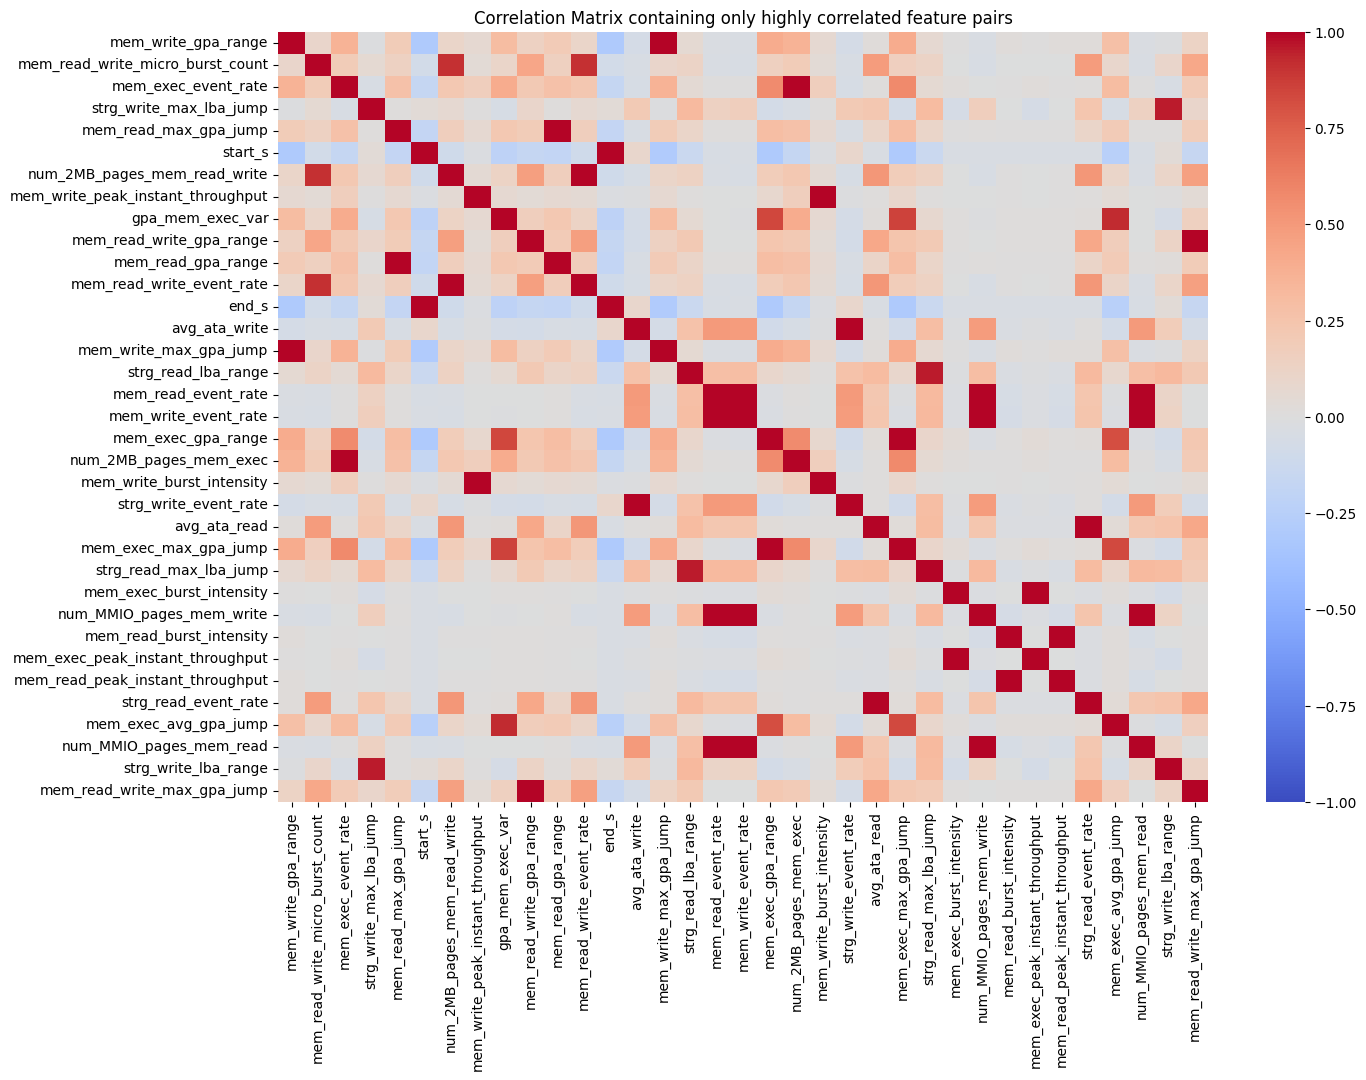

In [69]:
plt.figure(figsize=(15,10))
sns.heatmap(df_reduced[corr_mat_features].corr(), cmap='coolwarm', center=0, vmin=-1, vmax=1);
plt.title(f"Correlation Matrix containing only highly correlated feature pairs");

In [70]:
corr_with_target = df_reduced.drop(columns=['operation', 'operation_log_cnt']).corr(numeric_only=True)["is_ransomware"].drop("is_ransomware")
corr_sorted = corr_with_target.reindex(corr_with_target.abs().sort_values(ascending=False).index)

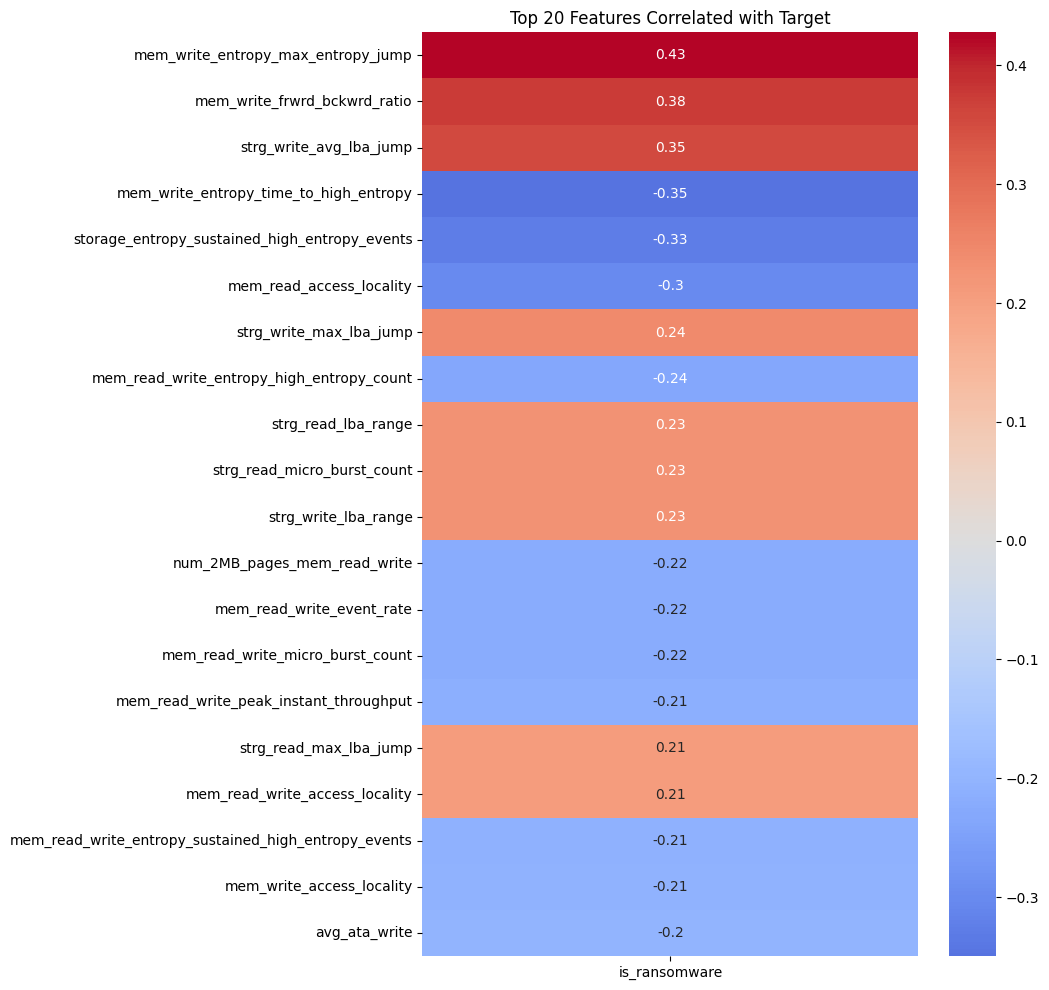

In [71]:
plt.figure(figsize=(8, 12))
sns.heatmap(corr_sorted[:20].to_frame(), annot=True, cmap="coolwarm", center=0)
plt.title("Top 20 Features Correlated with Target")
plt.show()

In [81]:
zero_var_cols

Index(['num_MMIO_pages_mem_read_write', 'num_MMIO_pages_mem_exec',
       'mem_exec_burst_clustering', 'mem_write_seq_addr_access_ratio',
       'mem_read_write_seq_addr_access_ratio',
       'mem_exec_seq_addr_access_ratio'],
      dtype='object')

In [80]:
zero_var_cols.to_list() + to_drop_high_corr

['num_MMIO_pages_mem_read_write',
 'num_MMIO_pages_mem_exec',
 'mem_exec_burst_clustering',
 'mem_write_seq_addr_access_ratio',
 'mem_read_write_seq_addr_access_ratio',
 'mem_exec_seq_addr_access_ratio',
 'num_MMIO_pages_mem_write',
 'strg_read_event_rate',
 'strg_write_event_rate',
 'mem_read_burst_intensity',
 'mem_read_event_rate',
 'mem_write_burst_intensity',
 'mem_write_event_rate',
 'mem_read_write_micro_burst_count',
 'mem_read_write_event_rate',
 'mem_exec_burst_intensity',
 'mem_exec_event_rate',
 'strg_read_lba_range',
 'strg_write_lba_range',
 'mem_read_gpa_range',
 'mem_write_gpa_range',
 'mem_read_write_gpa_range',
 'mem_exec_avg_gpa_jump',
 'mem_exec_gpa_range',
 'end_s']

In [ ]:
df_reduced = df_reduced.drop(columns=to_drop_high_corr)